## Imports and paths

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

## My Folder paths

In [82]:
BASE_DIR = Path.cwd().parent

RAW_CLEANED_DATA_DIR = BASE_DIR / "Data"

# Save
CLEANED_CLEANED_DATA_DIR = BASE_DIR / "Cleaned Data"
CLEANED_CLEANED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Input file
AUSTRALIA_FILE = RAW_CLEANED_DATA_DIR / "australia.csv"
OXCGRT_FILE = RAW_CLEANED_DATA_DIR / "OxCGRT_AUS_latest.csv"

## 1 Process policy data and identify mandate start dates

In [83]:
# Read OxCGRT
policy_df = pd.read_csv(OXCGRT_FILE)


# Needed columns
col_subsets = ["RegionName", "RegionCode", "Date", "H6M_Facial Coverings"]


# Convert date
policy_df.index = pd.to_datetime(policy_df["Date"], format="%Y%m%d")
policy_df = policy_df.loc[:, col_subsets]


# Identify mandate date
rolling_days = 14
policy_rolling =(policy_df.loc[:, ["RegionName", "H6M_Facial Coverings"]].groupby("RegionName").rolling(window=rolling_days).mean())  # 2 weeks rolling averages
mandate_limit = 3
mandate_start_df =(policy_rolling[policy_rolling["H6M_Facial Coverings"] >= mandate_limit].groupby("RegionName").head(1))


# Save
mandate_start_file = CLEANED_CLEANED_DATA_DIR / "mandate_start_dates.csv"
mandate_start_df.to_csv(mandate_start_file)


# Visualization
mandate_start_df.head()

,,H6M_Facial Coverings
RegionName,Date,
Australian Capital Territory,2021-08-18,3.000000
New South Wales,2021-07-09,3.000000
Northern Territory,2021-11-21,3.000000
Queensland,2021-01-17,3.142857
South Australia,2021-07-26,3.000000


## 2 Count missing values（ Australia survey data ）

In [84]:
# Read Australia data
missing_df = pd.read_csv(AUSTRALIA_FILE, na_values=[" ", "__NA__"], keep_default_na=True, low_memory=False)

# Count missing values
total_rows = len(missing_df)
missing_value_table = pd.DataFrame({"Variable Name": missing_df.columns, "Missing Value Count": missing_df.isna().sum().values})


missing_value_table["Missing Rate"] = (missing_value_table["Missing Value Count"] / total_rows)
missing_value_table = missing_value_table.sort_values(by=["Missing Value Count", "Variable Name"])


# Save
missing_value_file = CLEANED_CLEANED_DATA_DIR / "missing_value_counts.csv"
missing_value_table.to_csv(missing_value_file)


print("Total rows:", total_rows)
missing_value_table.head()

Total rows: 53833


,Variable Name,Missing Value Count,Missing Rate
0,RecordNo,0,0.0
72,age,0,0.0
76,employment_status,0,0.0
1,endtime,0,0.0
73,gender,0,0.0


## 3 Clean

### 3.1 Helper function

In [85]:
# Convert datetime
def convert_datetime(dt):
    date = dt.split()[0]
    return datetime.strptime(date, "%d/%m/%Y")


# Convert household size categories into numeric values
def household_convert(size_str):
    for i in range(1, 8):
        if size_str == str(i):
            return i
        elif size_str == "8 or more":
            return 8
        elif size_str == "Prefer not to say" or size_str == "Don't know":
            return None


### 3.2 Load and clean

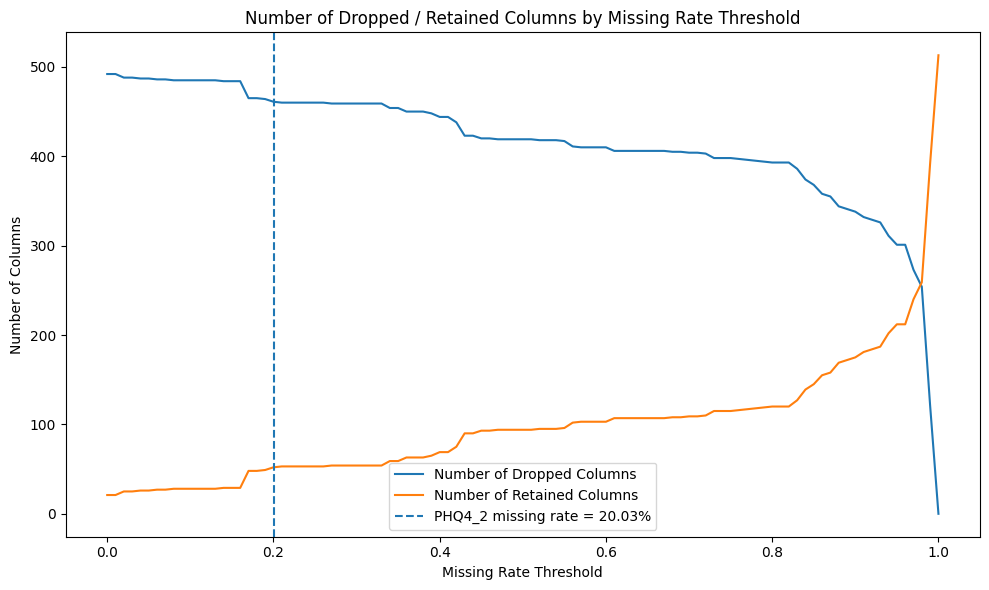

In [86]:
# Determine an appropriate threshold
# Visualise how the number of columns changes by missing rate threshold
thresholds = np.arange(0, 1.01, 0.01)
total_columns = len(missing_value_table)

dropped_counts = [(missing_value_table["Missing Rate"] > threshold).sum()for threshold in thresholds]
retained_counts = [total_columns - dropped for dropped in dropped_counts]


# Critical variable
critical_cols = ["PHQ4_1","PHQ4_2","PHQ4_3","PHQ4_4"]
critical_missing_table = missing_value_table[missing_value_table["Variable Name"].isin(critical_cols)].copy()
critical_threshold = critical_missing_table["Missing Rate"].max()
critical_col = critical_missing_table.loc[critical_missing_table["Missing Rate"].idxmax(),"Variable Name"]


plt.figure(figsize=(10, 6))
plt.plot(thresholds,dropped_counts,label="Number of Dropped Columns")
plt.plot( thresholds,retained_counts,label="Number of Retained Columns")
plt.axvline(critical_threshold,linestyle="--",label=f"{critical_col} missing rate = {critical_threshold:.2%}")
plt.xlabel("Missing Rate Threshold")
plt.ylabel("Number of Columns")
plt.title("Number of Dropped / Retained Columns by Missing Rate Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# Read
clean_df = pd.read_csv(AUSTRALIA_FILE,  na_values=[" ", "__NA__"],  keep_default_na=True)


# Convert endtime column to datetime
clean_df["endtime"] = clean_df["endtime"].apply(convert_datetime)


# Drop columns if missing rate is above the threshold
missing_rate_threshold = 0.3
missing_value_table = pd.read_csv(CLEANED_CLEANED_DATA_DIR / "missing_value_counts.csv")
columns_to_drop = missing_value_table.loc[missing_value_table["Missing Rate"] > missing_rate_threshold,  "Variable Name" ].tolist()
clean_df.drop(columns=columns_to_drop, inplace=True)


print("Number of dropped columns:", len(columns_to_drop))
print("Shape:", clean_df.shape)

C:\Users\22737\AppData\Local\Temp\ipykernel_19316\1322340314.py:2: DtypeWarning: Columns (0: i3_health, 1: i4_health, 2: i5_health_1, 3: i5_health_2, 4: i5_health_3, 5: i5_health_4, 6: i5_health_5, 7: i5_health_99, 8: i5a_health, 9: i6_health, 10: i7b_health, 11: i8_health, 12: i10_health, 13: i12_health_2, 14: i12_health_11, 15: i12_health_17, 16: i12_health_18, 17: i12_health_19, 18: i12_health_20, 19: d1_health_1, 20: d1_health_2, 21: d1_health_3, 22: d1_health_4, 23: d1_health_5, 24: d1_health_6, 25: d1_health_7, 26: d1_health_8, 27: d1_health_9, 28: d1_health_10, 29: d1_health_11, 30: d1_health_12, 31: d1_health_13, 32: d1_health_98, 33: d1_health_99, 34: WCRex2, 35: WCRV_4, 36: CORE_B2_4, 37: PHQ4_1, 38: PHQ4_2, 39: PHQ4_3, 40: PHQ4_4, 41: m1_1, 42: m1_2, 43: m1_3, 44: m1_4, 45: m4_1, 46: m4_2, 47: m4_3, 48: m4_4, 49: m4_96, 50: m4_99, 51: m4_other, 52: m5_1, 53: m5_2, 54: m6_1, 55: m6_2, 56: m6_3, 57: m6_4, 58: m6_5, 59: m6_6, 60: m6_7, 61: m6_8, 62: m6_96, 63: m6_other, 64: m7_

Number of dropped columns: 459
Shape: (53833, 54)


### 3.3 Fill missing medical variables during the consent period

( Statement: The approach and methods used in this part adopt the processing methods in Ryan et al. (2025). )

In [88]:
# Identify the date range where medical consent was not provided
sdate = pd.Timestamp("2021-02-10")
edate = pd.Timestamp("2021-10-18")
date_mask = (clean_df["endtime"] <= edate) & (clean_df["endtime"] >= sdate)

# Fill PHQ4 variables with "N/A" during the affected period
for i in range(1, 5):
    clean_df.loc[date_mask, f"PHQ4_{i}"] = clean_df.loc[date_mask, f"PHQ4_{i}"].fillna("N/A")

# Fill d1_health variables with "N/A" during the affected period
for i in range(1, 14):
    clean_df.loc[date_mask, f"d1_health_{i}"] = clean_df.loc[date_mask, f"d1_health_{i}"].fillna("N/A")

for i in range(98, 100):
    clean_df.loc[date_mask, f"d1_health_{i}"] = clean_df.loc[date_mask, f"d1_health_{i}"].fillna("N/A")

### 3.4 Drop remaining missing rows and recode variables

( Statement: The approach and methods used in this part adopt the processing methods in Ryan et al. (2025). )

In [89]:
# Remove all remaining rows with missing values
clean_df.dropna(inplace=True)

# Convert perception variables from text labels into numeric scores
for i in range(1, 3):
    clean_df[f"r1_{i}"] = clean_df[f"r1_{i}"].replace({ "7 - Agree": 7,  "6": 6,  "5": 5,  "4": 4,  "3": 3,  "2": 2,  "1 – Disagree": 1  })

# Convert protective behaviour frequency responses into numeric scores
frequency_dict = {"Always": 5,  "Frequently": 4,  "Sometimes": 3,  "Rarely": 2,  "Not at all": 1 }

for column in clean_df.columns:
    if column.startswith("i12_health_"):
        clean_df[column] = clean_df[column].map(frequency_dict)

print("Shape:", clean_df.shape)

Shape: (36349, 54)


### 3.5 Create behavioural scales and binary targets

( Statement: The approach and methods used in this part adopt the processing methods in Ryan et al. (2025). )

In [90]:
# Face mask behaviour scale
face_mask_cols = ["i12_health_1", "i12_health_22", "i12_health_23", "i12_health_25"]
clean_df["face_mask_behaviour_scale"] = clean_df[face_mask_cols].median(axis=1)
clean_df["face_mask_behaviour_binary"] = clean_df["face_mask_behaviour_scale"].apply(lambda x: "Yes" if x >= 4 else "No")


# Overall protective behaviour scale
protective_behaviour_cols = [col for col in clean_df.columns if col.startswith("i12_")]
clean_df["protective_behaviour_scale"] = clean_df[protective_behaviour_cols].median(axis=1)
clean_df["protective_behaviour_binary"] = clean_df["protective_behaviour_scale"].apply(lambda x: "Yes" if x >= 4 else "No")


# Protective behaviour scale excluding face mask
protective_behaviour_nomask_cols = [col for col in protective_behaviour_cols if col not in face_mask_cols]
clean_df["protective_behaviour_nomask_scale"] = clean_df[protective_behaviour_nomask_cols].median(axis=1)
clean_df[[
    "face_mask_behaviour_scale",
    "face_mask_behaviour_binary",
    "protective_behaviour_scale",
    "protective_behaviour_binary",
    "protective_behaviour_nomask_scale"]].head()

,face_mask_behaviour_scale,face_mask_behaviour_binary,protective_behaviour_scale,protective_behaviour_binary,protective_behaviour_nomask_scale
14059,4.5,Yes,4.0,Yes,4.0
14060,1.0,No,5.0,Yes,5.0
14061,4.5,Yes,4.0,Yes,4.0
14062,5.0,Yes,5.0,Yes,5.0
14063,1.0,No,1.0,No,2.5


### 3.6 Collapse comorbidity variables and create week number

In [91]:
# Combine
d1_cols = [col for col in clean_df.columns if col.startswith("d1_")]
clean_df["d1_comorbidities"] = "Yes"
clean_df.loc[clean_df["d1_health_99"] == "Yes", "d1_comorbidities"] = "No"
clean_df.loc[clean_df["d1_health_99"] == "N/A", "d1_comorbidities"] = "NA"
clean_df.loc[clean_df["d1_health_98"] == "Yes", "d1_comorbidities"] = "Prefer_not_to_say"


# Drop d1 columns
clean_df = clean_df.drop(d1_cols, axis=1)


# Week variable
start_date = clean_df["endtime"].min()
clean_df["week_number"] = ((clean_df["endtime"] - start_date).dt.days // 14) + 1

### 3.7 Convert household size, drop extra columns, save cleaned data

In [92]:
# Convert household size into numeric form
clean_df["household_size"] = clean_df["household_size"].apply(household_convert)


# Drop rows with induced missing values after household conversion
clean_df.dropna(inplace=True)


# Drop survey weighting, original qweek, and the original protective behaviour item columns
clean_df = clean_df.drop(["qweek", "weight"] + protective_behaviour_cols, axis=1)


# Save
cleaned_data_file = CLEANED_CLEANED_DATA_DIR / "cleaned_data.csv"
clean_df.to_csv(cleaned_data_file, index=False)


print("Final cleaned dataset shape:", clean_df.shape)
clean_df.head()

Final cleaned dataset shape: (35460, 26)


,RecordNo,endtime,i2_health,i9_health,i11_health,age,gender,state,household_size,employment_status,...,WCRex1,r1_1,r1_2,face_mask_behaviour_scale,face_mask_behaviour_binary,protective_behaviour_scale,protective_behaviour_binary,protective_behaviour_nomask_scale,d1_comorbidities,week_number
14059,14059,2020-09-02,0.0,No,Very unwilling,25,Male,Victoria,8.0,Full time employment,...,Somewhat well,6,7,4.5,Yes,4.0,Yes,4.0,Yes,1
14060,14060,2020-09-02,0.0,Yes,Very willing,70,Male,New South Wales,2.0,Retired,...,Somewhat badly,6,4,1.0,No,5.0,Yes,5.0,Yes,1
14061,14061,2020-09-02,0.0,No,Somewhat willing,23,Female,Victoria,4.0,Part time employment,...,Somewhat well,6,5,4.5,Yes,4.0,Yes,4.0,No,1
14062,14062,2020-09-02,3.0,Yes,Very willing,25,Male,New South Wales,2.0,Full time employment,...,Somewhat well,2,1,5.0,Yes,5.0,Yes,5.0,No,1
14063,14063,2020-09-02,20.0,Yes,Very willing,64,Male,New South Wales,3.0,Full time employment,...,Somewhat well,2,2,1.0,No,1.0,No,2.5,Yes,1


## 4 Preprocess the cleaned data for modelling


### 4.1 Helper function for mandate period assignment

In [93]:
def mandates_convert(row):
    # Convert a row into a binary indicator for whether it falls within the mandate period
    endtime = pd.to_datetime(row["endtime"], format="%Y-%m-%d")
    state = row["state"]

    if states_date[state][0] <= endtime:
        return 1
    else:
        return 0

### 4.2 Load cleaned data and mandate dates

In [97]:
# Read 
preprocess_df = pd.read_csv(CLEANED_CLEANED_DATA_DIR / "cleaned_data.csv", keep_default_na=False)   # The cleaned survey data  
mandate_df = pd.read_csv(CLEANED_CLEANED_DATA_DIR / "mandate_start_dates.csv")                      # The derived mandate start dates


# Dictionary of mandate start dates
states_date = {}
for state, date in zip(mandate_df["RegionName"], mandate_df["Date"]):
    states_date.update({state: [date]})
    
for state, date_range in states_date.items():
    states_date[state] = [pd.to_datetime(date, format="%Y-%m-%d") for date in date_range]


# Binary mandate-period indicator
preprocess_df["within_mandate_period"] = preprocess_df.apply(mandates_convert, axis=1)
preprocess_df[["state", "endtime", "within_mandate_period"]].head()

,state,endtime,within_mandate_period
0,Victoria,2020-09-02,1
1,New South Wales,2020-09-02,0
2,Victoria,2020-09-02,1
3,New South Wales,2020-09-02,0
4,New South Wales,2020-09-02,0


### 4.3 Create dummy variables and save preprocessed data

In [98]:
# Convert selected categorical variables into dummy variables
convert_into_dummy_cols = ["state","gender","i9_health","employment_status","i11_health","WCRex1","WCRex2","PHQ4_1","PHQ4_2","PHQ4_3","PHQ4_4","d1_comorbidities"]


for col in convert_into_dummy_cols:
    dummy = pd.get_dummies(preprocess_df[col], prefix=col, drop_first=True)
    preprocess_df = pd.concat([preprocess_df, dummy], axis=1)
    preprocess_df = preprocess_df.drop(col, axis=1)


# Save
preprocessed_file = CLEANED_CLEANED_DATA_DIR / "cleaned_data_preprocessing.csv"
preprocess_df.to_csv(preprocessed_file, index=False)


print("Preprocessed dataset shape:", preprocess_df.shape)
preprocess_df.head()

Preprocessed dataset shape: (35460, 65)


,RecordNo,endtime,i2_health,age,household_size,cantril_ladder,r1_1,r1_2,face_mask_behaviour_scale,face_mask_behaviour_binary,...,PHQ4_3_Prefer not to say,PHQ4_3_Several days,PHQ4_4_N/A,PHQ4_4_Nearly every day,PHQ4_4_Not at all,PHQ4_4_Prefer not to say,PHQ4_4_Several days,d1_comorbidities_No,d1_comorbidities_Prefer_not_to_say,d1_comorbidities_Yes
0,14059,2020-09-02,0.0,25,8.0,1.0,6,7,4.5,Yes,...,False,False,False,True,False,False,False,False,False,True
1,14060,2020-09-02,0.0,70,2.0,7.0,6,4,1.0,No,...,False,False,False,False,True,False,False,False,False,True
2,14061,2020-09-02,0.0,23,4.0,3.0,6,5,4.5,Yes,...,False,False,False,False,False,False,False,True,False,False
3,14062,2020-09-02,3.0,25,2.0,8.0,2,1,5.0,Yes,...,False,False,False,False,True,False,False,True,False,False
4,14063,2020-09-02,20.0,64,3.0,7.0,2,2,1.0,No,...,False,True,False,False,True,False,False,False,False,True
